In [41]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from typing import List, Optional, Dict, Any, TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

In [27]:
# State Graph

class AssistantState(TypedDict):

    # Conversation
    messages: List[Dict[str, Any]]
    current_query: str

    # Routing
    detected_domains: List[str]
    intent: Optional[str]
    routing_confidence: float

    # Agent result
    agent_response: Optional[str]
    agent_confidence: float
    solved: bool

    # Human handoff
    human_required: bool
    handoff_reason: Optional[str]
    ticket_id: Optional[str]

    # Grounding
    sources: List[str]

    # Final response
    final_answer: Optional[str]

    # Misc
    metadata: Dict[str, Any]          

In [28]:
# Structured output

class DepartmentRoute(BaseModel):
    route: Literal["IT", "HR", "Fees", "Facilities", "Admissions", "Academics", "General", "Human"]
    departments: List[Literal["IT", "HR", "Fees", "Facilities", "Admissions", "Academics", "General"]]
    understood: bool
    confidence: float = Field(ge=0.0, le=1.0)
    reason: str

In [29]:
system_prompt = """
You are the campus assistant's query-routing system.

Your only task is to route the user's query to the correct department.

Available departments:
- IT: accounts, passwords, Wi-Fi, software, computers, technical issues
- HR: employment, leave, payroll, benefits, workplace policies
- Fees: tuition, invoices, payments, refunds, financial aid
- Facilities: buildings, rooms, maintenance, transport, security, access
- Admissions: applications, enrollment, eligibility, deadlines
- Academics: courses, grades, exams, schedules, academic policies
- General: clear questions that do not belong to another department

Routing rules:
1. Route clear queries to the most appropriate department.
2. If one query clearly concerns multiple departments, include all relevant departments.
3. Route to "Human" only when you cannot understand the user's intent.
4. Do not route to "Human" just because the query is unusual or has low confidence.
5. Use "Human" for vague queries such as "Help me", unintelligible text,
   or queries with no understandable purpose.
6. Never answer the user's question.
7. Return data that matches the schema exactly.
"""

In [30]:
from agents import (
    router,
    it_agent,
    clarify,
    hr_agent,
    fees_agent,
    facilities_agent,
    synthesize,
    respond,
    route_by_confidence,
    continue_conversation,
)

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AssistantState)

builder.add_node("router", router)
builder.add_node("clarify", clarify)

builder.add_node("it_agent", it_agent)
builder.add_node("hr_agent", hr_agent)
builder.add_node("fees_agent", fees_agent)
builder.add_node("facilities_agent", facilities_agent)

builder.add_node("synthesize", synthesize)
builder.add_node("respond", respond)

builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    route_by_confidence,
    {
        "clarify": "clarify",
        "it": "it_agent",
        "hr": "hr_agent",
        "fees": "fees_agent",
        "facilities": "facilities_agent",
    }
)

builder.add_edge("clarify", "router")

builder.add_edge("it_agent", "synthesize")
builder.add_edge("hr_agent", "synthesize")
builder.add_edge("fees_agent", "synthesize")
builder.add_edge("facilities_agent", "synthesize")

builder.add_edge("synthesize", "respond")

graph = builder.compile()

In [32]:
agent = builder.compile()

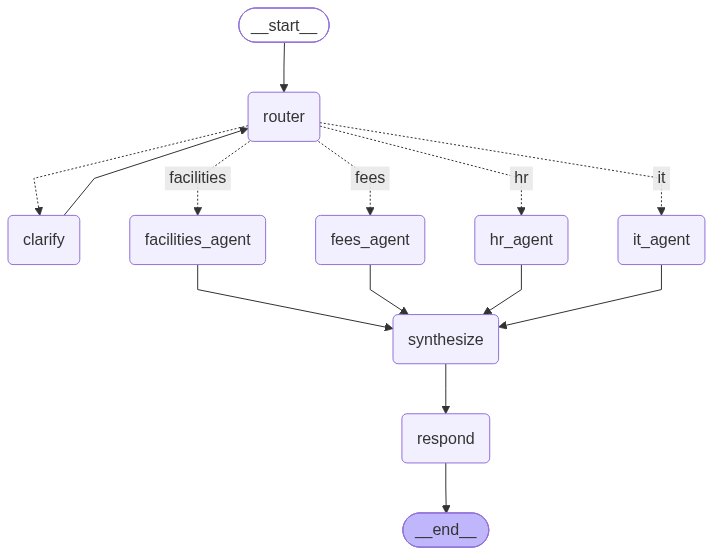

In [33]:
agent

In [34]:
chat_history = ""
user_query = "I forgot my Wi‑Fi password and need access"

In [35]:
messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(
        content=f"""
Conversation history:
{chat_history}

User query:
{user_query}
"""
    )
]

In [36]:
initial_state = {
    "messages": [],
    "current_query": user_query,
    "detected_domains": [],
    "intent": None,
    "routing_confidence": 0.0,
    "agent_response": None,
    "agent_confidence": 0.0,
    "solved": False,
    "human_required": False,
    "handoff_reason": None,
    "ticket_id": None,
    "sources": [],
    "final_answer": None,
    "metadata": {},
}

In [37]:
result = agent.invoke(initial_state)

In [38]:
print(result)

{'messages': [{'role': 'assistant', 'content': '**How to recover or reset your Wi‑Fi password**\n\n1. **View the saved password on a device that’s still connected**  \n   - **Windows 10/11:** Settings → Network & Internet → Status → Network and Sharing Center → click the Wi‑Fi name →\u202fWireless Properties →\u202fSecurity → check **Show characters**.  \n   - **macOS:** Open *Keychain Access*, find the Wi‑Fi SSID, double‑click it, then check **Show password** (enter your admin password).  \n   - **iOS\u202f16+:** Settings → Wi‑Fi → tap **i** next to the network → tap **Password** (authenticate with Face/Touch ID).  \n   - **Android\u202f10+:** Settings → Network & internet → Wi‑Fi → tap the network → **Share** (QR code) → authenticate; the QR code contains the password.\n\n2. **Check the router’s label** – many routers have a sticker on the back/bottom that lists the default SSID and password (e.g., “Wi‑Fi Key”). This works only if the password has never been changed.\n\n3. **Log into

In [39]:
result["final_answer"]

'**How to recover or reset your Wi‑Fi password**\n\n1. **View the saved password on a device that’s still connected**  \n   - **Windows 10/11:** Settings → Network & Internet → Status → Network and Sharing Center → click the Wi‑Fi name →\u202fWireless Properties →\u202fSecurity → check **Show characters**.  \n   - **macOS:** Open *Keychain Access*, find the Wi‑Fi SSID, double‑click it, then check **Show password** (enter your admin password).  \n   - **iOS\u202f16+:** Settings → Wi‑Fi → tap **i** next to the network → tap **Password** (authenticate with Face/Touch ID).  \n   - **Android\u202f10+:** Settings → Network & internet → Wi‑Fi → tap the network → **Share** (QR code) → authenticate; the QR code contains the password.\n\n2. **Check the router’s label** – many routers have a sticker on the back/bottom that lists the default SSID and password (e.g., “Wi‑Fi Key”). This works only if the password has never been changed.\n\n3. **Log into the router’s admin interface** (requires admin

In [40]:
result["detected_domains"]

['IT']